<a href="https://colab.research.google.com/github/EsmeBarker/Collab/blob/main/Copy_of_Unit7ExercisesSF1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

Polynomials can be helpful when you have data with more complicated relationships. I feel like I can mostly see this being useful for data that has multiple dips or peaks, with degree varying based on how many.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

If the trend your data follows is simple, i.e., a line or curve with a consistently positive or negative slope, a polynomial will only worsen the fit. Even if the fit looks pretty good with a high degree polynomial, if a simpler model looks about the same it is the better option.

**Task3**:

What's the point of using b splines?

B splines give you more flexibility and control over how your model fits the data. You can adjust specific parts of the curve to fit the data better instead of having to change the entire model.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

They are like NNs that treat every possible data point as a knot and then find the relationships between all of those different knots. It uses the points closeness to determine how related they are and finds relationships within the data points.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install bambi

In [2]:
import pandas as pd
import bambi as bmb
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt
import numpy as np

In [3]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [ ]:
model_poly = bmb.Model("weight ~ poly(height, degree=4)", howell, family="negativebinomial")
idata_poly = model_poly.fit()

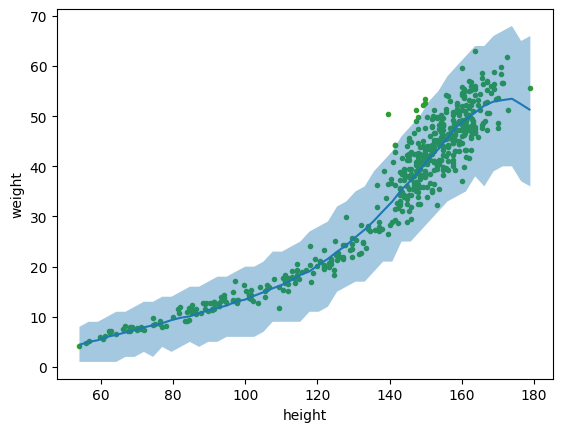

In [ ]:
bmb.interpret.plot_predictions(model_poly, idata_poly, conditional="height", pps=True)
plt.plot(howell.height,howell.weight,"C2.", zorder=-3)

In [ ]:
num_knots = 6
knots = np.linspace(howell.height.min(), howell.height.max(), num_knots+2)[1:-1]
model_bspline = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell, family="negativebinomial")
idata_bspline = model_bsplines.fit()

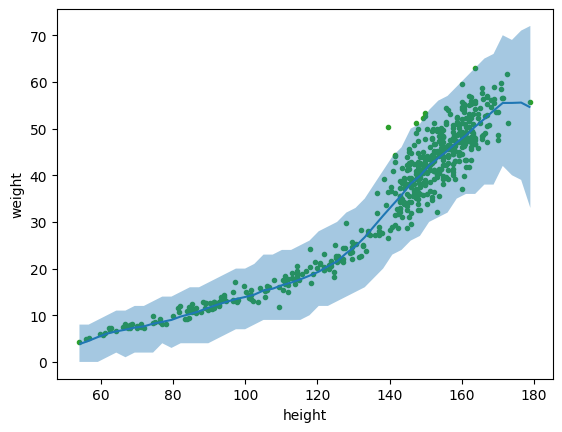

In [ ]:
bmb.interpret.plot_predictions(model_bspline, idata_bspline, conditional="height", pps=True)
plt.plot(howell.height,howell.weight,"C2.", zorder=-3)

In [ ]:
prior_gp = {
    "sigma": bmb.Prior("Exponential", lam=1),   # amplitude
    "ell":   bmb.Prior("Exponential", lam=1),   # lengthscale
}

priors = {
    "hsgp(height, m=60, c=4)": prior_gp,
    "sigma": bmb.Prior("HalfNormal", sigma=5),  # obs SD
    "alpha": bmb.Prior("Normal", mu=0, sigma=5)
}

model_gp = bmb.Model(
    "weight ~ 1 + hsgp(height, m=60, c=4)",
    howell,
    family="gaussian",          # <- key change
    priors=priors
)

idata_gp = model_gp.fit(target_accept=0.9)


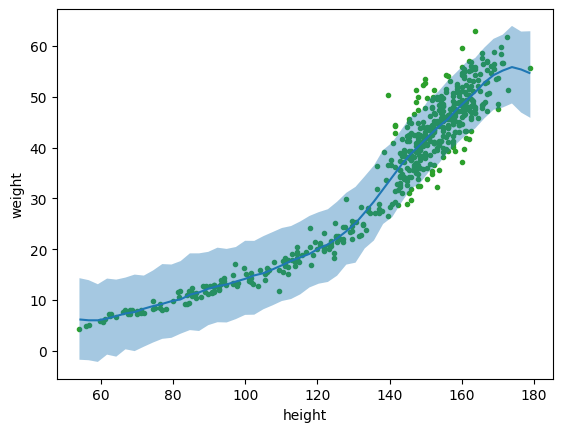

In [5]:
bmb.interpret.plot_predictions(model_gp, idata_gp, conditional="height", pps=True)
plt.plot(howell.height,howell.weight,"C2.", zorder=-3)

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

In the article, they didn't specify any function that would be the mean of the GP, so it wanted to move back towards zero. I learned that this is something you need to look out for with GPs, or else they can give inaccurate predictions.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

It is a graph of atmospheric CO2 data from the year 13 to 2004. The first almost 2000 years on the graph show data taken from ice cores estimating average C02 over 2-4 years. The data from the late 1950s onwards is from the Mauna Loa observatory. The data from the Mauna Loa observatory matches the ice core data really well at first glance, but when you zoom in closer you can see that there are seasonal changes in atmospheric C02 that the Mauna Loa observatory was able to track but the ice core data could not. I thought this was interesting because it shows the weaknesses in the ice core data really clearly. It's easy to be aware that there are weaknesses but not really understand it, and this graph allowed me to see the actual difference.